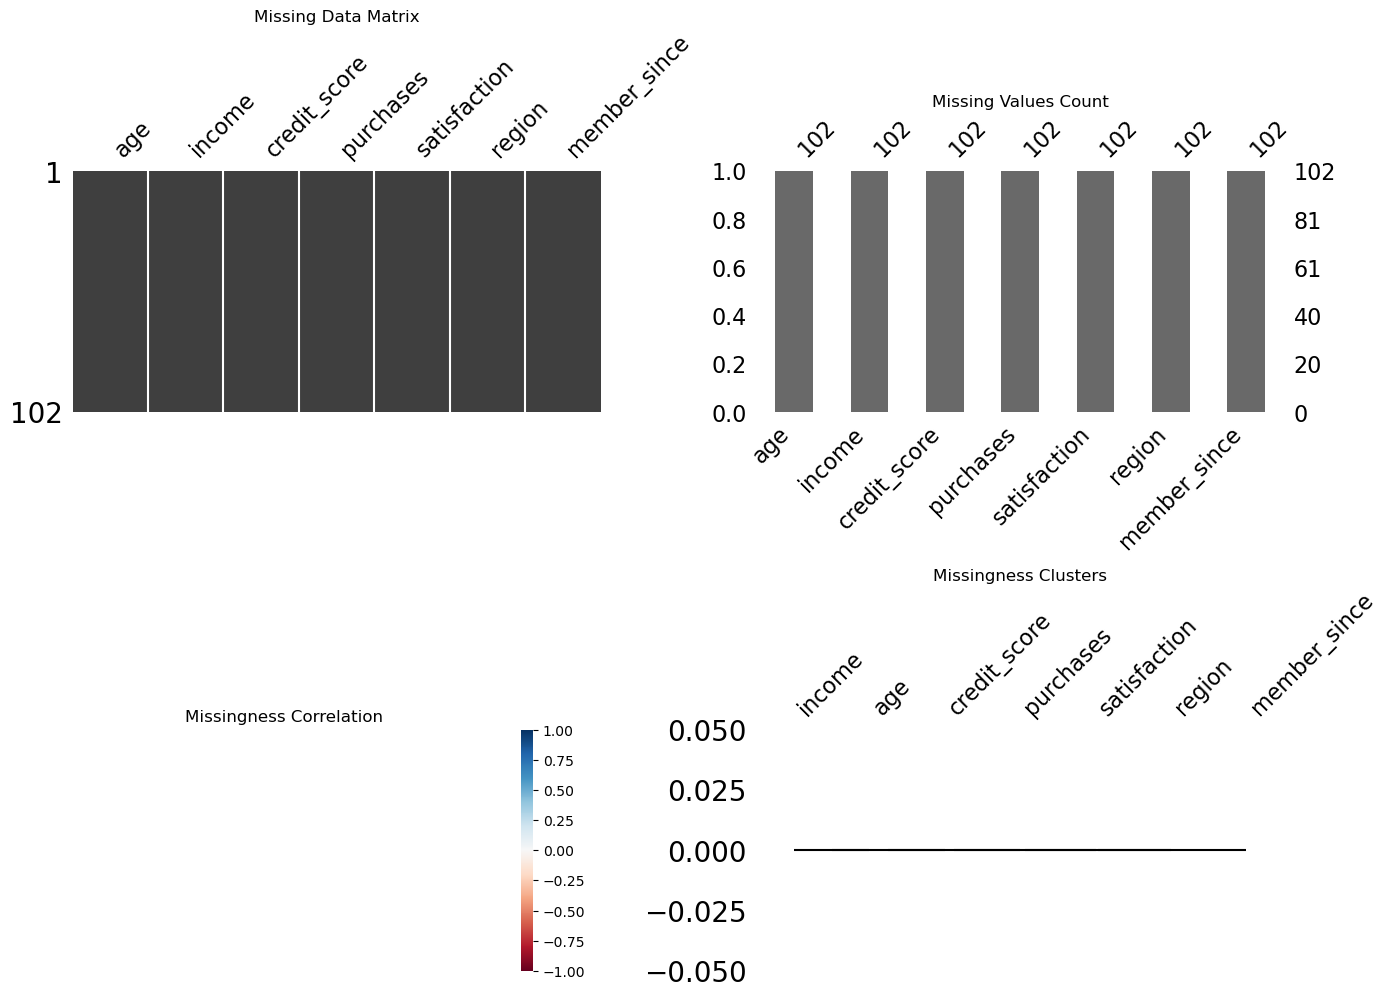

In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import warnings
# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')
# Load dataset
df = pd.read_csv('customer_data.csv')
# Visualize missing data patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Matrix plot (white = missing)
msno.matrix(df, ax=axes[0, 0])
axes[0, 0].set_title('Missing Data Matrix')
# Bar chart of missing values
msno.bar(df, ax=axes[0, 1])
axes[0, 1].set_title('Missing Values Count')
# Heatmap of missingness correlation
msno.heatmap(df, ax=axes[1, 0])
axes[1, 0].set_title('Missingness Correlation')
# Dendrogram of missingness patterns
msno.dendrogram(df, ax=axes[1, 1])
axes[1, 1].set_title('Missingness Clusters')
plt.tight_layout()
plt.show()

In [25]:
# Create a copy for experimentation
df_clean = df.copy()
# 1. SIMPLE DELETION METHODS
#--------------------------
# Drop rows with any missing values (use cautiously!)
df_drop_any = df.dropna()
print(f"After dropping any missing: {len(df_drop_any)} rows remain")
# Drop rows where specific columns have missing
df_drop_subset = df.dropna(subset=['age', 'income', 'credit_score'])
print(f"After dropping missing in key columns: {len(df_drop_subset)} rows remain")
# Drop columns with too many missing
threshold = 0.3 # 30% missing
df_drop_cols = df.dropna(thresh=int(len(df) * (1- threshold)), axis=1)
print(f"Columns after dropping high-missing columns: {df_drop_cols.columns.tolist()}")
# 2. SIMPLE IMPUTATION METHODS
#----------------------------
# Mean/Median imputation
df_mean = df.copy()
df_mean['age'] = df_mean['age'].fillna(df_mean['age'].mean())
df_mean['income'] = df_mean['income'].fillna(df_mean['income'].median()) # Median robust to outliers
# Mode imputation for categorical
df_mean['region'] = df_mean['region'].fillna(df_mean['region'].mode()[0])
# Constant imputation
df_constant = df.copy()
df_constant['satisfaction'] = df_constant['satisfaction'].fillna(3) # Neutral value
df_constant['purchases'] = df_constant['purchases'].fillna(0) # Assume no purchases
# Forward/Backward fill (for time series)
df_ffill = df.copy()
df_ffill = df_ffill.sort_values('member_since') # Ensure chronological order
df_ffill['credit_score'] = df_ffill['credit_score'].fillna(method='ffill')
df_ffill['credit_score'] = df_ffill['credit_score'].fillna(method='bfill') # For leading NAs
# 3. ADVANCED IMPUTATION METHODS
#------------------------------
# Group-based imputation
df_group = df.copy()
df_group['age'] = df_group.groupby('region')['age'].transform(
lambda x: x.fillna(x.mean())
)
# Linear interpolation (for ordered data)
df_interp = df.copy()
df_interp = df_interp.sort_values('member_since')
df_interp['credit_score'] = df_interp['credit_score'].interpolate(method='linear')
# KNNimputation (requires sklearn)
from sklearn.impute import KNNImputer
# Select numerical columns for KNN imputation
numerical_cols = ['age', 'income', 'credit_score', 'purchases', 'satisfaction']
df_knn = df[numerical_cols].copy()
# Apply KNN imputation
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    imputer.fit_transform(df_knn),
    columns=numerical_cols
)
# 4. CREATING "MISSINGNESS" FEATURES
#----------------------------------
# Sometimes the fact that a value is missing is informative
df_with_flag = df.copy()
for col in numerical_cols:
    missing_flag_col = f"{col}_missing"
    df_with_flag[missing_flag_col] = df_with_flag[col].isnull().astype(int)
print("\nColumns with missing flags added:")
print(df_with_flag.filter(like='_missing').head())


After dropping any missing: 102 rows remain
After dropping missing in key columns: 102 rows remain
Columns after dropping high-missing columns: ['age', 'income', 'credit_score', 'purchases', 'satisfaction', 'region', 'member_since']

Columns with missing flags added:
   age_missing  income_missing  credit_score_missing  purchases_missing  \
0            0               0                     0                  0   
1            0               0                     0                  0   
2            0               0                     0                  0   
3            0               0                     0                  0   
4            0               0                     0                  0   

   satisfaction_missing  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  


In [26]:
# Create a function to evaluate imputation
def evaluate_imputation(original_df, imputed_df, cols_with_missing):
    """
    Compare original (with missing) and imputed dataframes.
    Note: This is a simplified evaluation since we don't know true values.
    In practice, you might artificially create missing values from complete data
    to evaluate imputation accuracy.
    """
    results = {}
    for col in cols_with_missing:
        # Get indices where original was missing
        missing_idx = original_df[col].isnull()
        if missing_idx.sum() > 0:
            # Compare distributions
            orig_stats = original_df[col].describe()
            imputed_stats = imputed_df.loc[missing_idx, col].describe()
            results[col] = {
                'n_missing': missing_idx.sum(),
                'orig_mean': orig_stats['mean'],
                'imputed_mean': imputed_stats['mean'],
                'orig_std': orig_stats['std'],
                'imputed_std': imputed_stats['std']
            }
    return pd.DataFrame(results).T
# Compare different methods
cols_with_missing = ['age', 'income', 'credit_score', 'purchases', 'satisfaction']
print("Mean Imputation Results:")
print(evaluate_imputation(df, df_mean, cols_with_missing))
print("\nGroup Imputation Results:")
print(evaluate_imputation(df, df_group, cols_with_missing))

Mean Imputation Results:
Empty DataFrame
Columns: []
Index: []

Group Imputation Results:
Empty DataFrame
Columns: []
Index: []
